# Plant Disease Detection System

## Deep Learning Based Leaf Disease Classifier

**Model:** PlantDiseaseNet (Custom CNN) 
**Accuracy:** 99.47% 
**Classes:** 38 plant diseases

---

### Notebook Overview

This notebook demonstrates a complete plant disease detection system using a custom CNN architecture.

**What you'll find here:**
- Environment setup (works on both local and Google Colab)
- Model loading and evaluation
- Training history visualization
- Real-time disease prediction on uploaded images
- Model architecture details

**Instructions:**
- Run each cell in sequence by clicking the play button or pressing `Shift + Enter`
- For Google Colab: Upload the project zip file when prompted
- For Local: Just run the cells sequentially

---
## Step 1: Environment Detection & Setup

In [27]:
import sys
import os

# Detect environment
IN_COLAB = 'google.colab' in sys.modules

print("="*60)
print(" Plant Disease Detection System")
print("="*60)
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local Jupyter'}")
print(f"Python Version: {sys.version.split()[0]}")
print("="*60)

 Plant Disease Detection System
Environment: Local Jupyter
Python Version: 3.9.6


### Setup Project Files (Google Colab Only)

**For Google Colab users:** Choose ONE of the following options:
- **Option A:** Upload zip file from Google Drive
- **Option B:** Upload zip file directly

**For Local users:** Skip to the next section

In [28]:
if IN_COLAB:
    print(" Setting up project files for Google Colab...")
    print("\n[WARNING] IMPORTANT: Choose ONE option below:")
    print(" - Run EITHER 'Option A' (Google Drive) OR 'Option B' (Direct Upload)")
    print(" - Do NOT run both!\n")
else:
    print("[OK] Running locally - no setup needed")
    # Change to project root if running from notebooks folder
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')
    print(f"Working directory: {os.getcwd()}")

[OK] Running locally - no setup needed
Working directory: /Users/abdulrafay/Documents/leaf-disease-detection


#### Option A: Mount Google Drive (Recommended for Colab)

In [ ]:
# OPTION A: Use this if you uploaded the zip to Google Drive
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    
    # Update this path to match where you saved the zip in your Drive
    zip_path = '/content/drive/MyDrive/AI_Semester_Project/leaf-disease-detection.zip'
    
    print(f"\nUnzipping project from: {zip_path}")
    !unzip -q {zip_path} -d /content/
    
    # Change to project directory
    %cd /content/leaf-disease-detection
    print("[OK] Project files extracted successfully!")
else:
    print("Skipping - not in Colab environment")

Skipping - not in Colab environment


#### Option B: Direct Upload (Alternative for Colab)

In [30]:
# OPTION B: Use this to upload the zip file directly
# WARNING: Only run this if you didn't use Option A above!

if IN_COLAB:
    from google.colab import files
    
    print("📤 Upload your leaf-disease-detection.zip file:")
    uploaded = files.upload()
    
    if uploaded:
        zip_name = list(uploaded.keys())[0]
        print(f"\nUnzipping {zip_name}...")
        !unzip -q {zip_name} -d /content/
        
        # Change to project directory
        %cd /content/leaf-disease-detection
        print("[OK] Project files extracted successfully!")
else:
    print("Skipping - not in Colab environment")

Skipping - not in Colab environment


---
## 📚 Step 2: Install Dependencies

In [31]:
if IN_COLAB:
    print("Installing dependencies for Google Colab...")
    !pip install -q -r requirements-colab.txt
    print("All dependencies installed!")
else:
    print("Using local environment dependencies")
    # Verify key packages are available
    try:
        import tensorflow as tf
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        print(f"TensorFlow version: {tf.__version__}")
        print(f"NumPy version: {np.__version__}")
        print(f"Pandas version: {pd.__version__}")
    except ImportError as e:
        print(f"[ERROR] Missing package: {e}")
        print("Please install: pip install -r requirements.txt")

Using local environment dependencies
TensorFlow version: 2.15.0
NumPy version: 1.24.3
Pandas version: 2.1.4


---
## Step 3: Verify Project Structure

In [32]:
import os

print("📁 Project Structure:")
print("="*60)

# Check key directories and files
required_items = [
    ('config.yaml', 'file'),
    ('src/', 'dir'),
    ('app/', 'dir'),
    ('models/saved_models/', 'dir'),
    ('models/saved_models/best_model.keras', 'file'),
    ('models/saved_models/training_history.json', 'file'),
    ('data/splits/class_mapping.json', 'file')
]

all_present = True
for item, item_type in required_items:
    if item_type == 'file':
        exists = os.path.isfile(item)
        symbol = "[OK]" if exists else "✗"
        print(f"{symbol} {item}")
        if exists and 'best_model.keras' in item:
            size_mb = os.path.getsize(item) / (1024*1024)
            print(f" └─ Size: {size_mb:.1f} MB")
    else:
        exists = os.path.isdir(item)
        symbol = "[OK]" if exists else "✗"
        print(f"{symbol} {item}")
    
    if not exists:
        all_present = False

print("="*60)
if all_present:
    print("[OK] All required files present!")
else:
    print("[WARNING] Some files are missing. Please check your project structure.")

📁 Project Structure:
[OK] config.yaml
[OK] src/
[OK] app/
[OK] models/saved_models/
[OK] models/saved_models/best_model.keras
 └─ Size: 309.2 MB
[OK] models/saved_models/training_history.json
[OK] data/splits/class_mapping.json
[OK] All required files present!


---
## Step 4: Load the Trained Model

In [33]:
import tensorflow as tf
import json
import numpy as np

print("Loading trained model...")
print("="*60)

# Load model
model_path = 'models/saved_models/best_model.keras'
model = tf.keras.models.load_model(model_path)
print(f"[OK] Model loaded from: {model_path}")

# Load class mapping
with open('data/splits/class_mapping.json', 'r') as f:
    class_mapping = json.load(f)
    # Convert string keys to integers
    class_mapping = {int(k): v for k, v in class_mapping.items()}

print(f"[OK] Loaded {len(class_mapping)} disease classes")
print("="*60)

# Display model summary
print("\n Model Architecture Summary:")
print("="*60)
model.summary()

# Count parameters
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print("="*60)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-trainable Parameters: {non_trainable_params:,}")
print("="*60)

Loading trained model...
[OK] Model loaded from: models/saved_models/best_model.keras
[OK] Loaded 38 disease classes

 Model Architecture Summary:
Model: "PlantDiseaseNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 32)      896       
                                                                 
 block1_bn1 (BatchNormaliza  (None, 224, 224, 32)      128       
 tion)                                                           
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 32)      9248      
                                                                 
 block1_bn2 (BatchNormaliza  (None, 224, 224, 32)      128       
 tion)                              

---
## Step 5: Visualize Training History

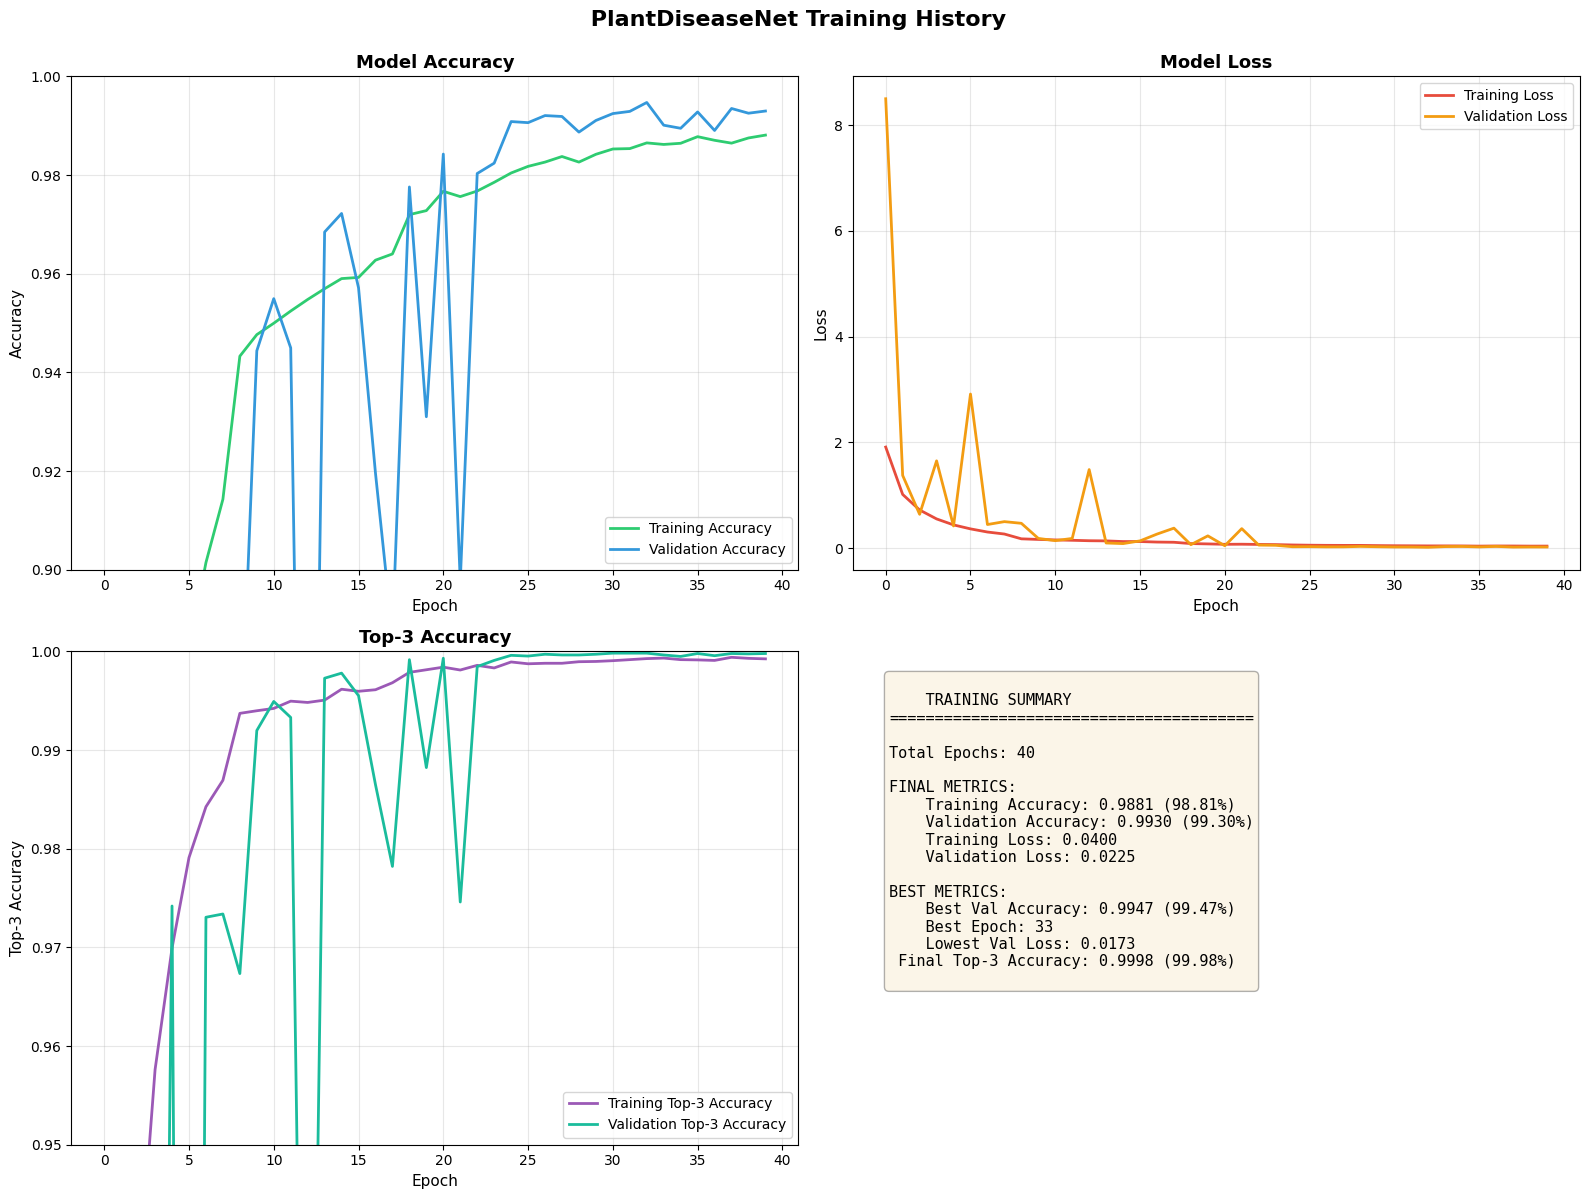


 DETAILED TRAINING METRICS
Total Epochs Trained: 40

Final Epoch Results:
 Training Accuracy: 0.9881 (98.81%)
 Validation Accuracy: 0.9930 (99.30%)
 Training Loss: 0.0400
 Validation Loss: 0.0225

Best Results:
 Best Validation Accuracy: 0.9947 (99.47%)
 Achieved at Epoch: 33
 Lowest Validation Loss: 0.0173

Top-3 Accuracy:
 Final Top-3 Accuracy: 0.9998 (99.98%)
 Best Top-3 Accuracy: 0.9998 (99.98%)


In [34]:
import matplotlib.pyplot as plt
import json

# Load training history
with open('models/saved_models/training_history.json', 'r') as f:
    history = json.load(f)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' PlantDiseaseNet Training History', fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Accuracy
axes[0, 0].plot(history['accuracy'], label='Training Accuracy', linewidth=2, color='#2ecc71')
axes[0, 0].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#3498db')
axes[0, 0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].legend(loc='lower right', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.9, 1.0])

# Plot 2: Loss
axes[0, 1].plot(history['loss'], label='Training Loss', linewidth=2, color='#e74c3c')
axes[0, 1].plot(history['val_loss'], label='Validation Loss', linewidth=2, color='#f39c12')
axes[0, 1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].legend(loc='upper right', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Top-3 Accuracy (if available)
if 'top_3_accuracy' in history:
    axes[1, 0].plot(history['top_3_accuracy'], label='Training Top-3 Accuracy', linewidth=2, color='#9b59b6')
    axes[1, 0].plot(history['val_top_3_accuracy'], label='Validation Top-3 Accuracy', linewidth=2, color='#1abc9c')
    axes[1, 0].set_title('Top-3 Accuracy', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch', fontsize=11)
    axes[1, 0].set_ylabel('Top-3 Accuracy', fontsize=11)
    axes[1, 0].legend(loc='lower right', fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0.95, 1.0])
else:
    axes[1, 0].text(0.5, 0.5, 'Top-3 Accuracy\nNot Available', 
    ha='center', va='center', fontsize=12, color='gray')
    axes[1, 0].set_xticks([])
    axes[1, 0].set_yticks([])

# Plot 4: Training Summary Table
axes[1, 1].axis('off')
summary_text = f"""
    TRAINING SUMMARY
{'='*40}

Total Epochs: {len(history['accuracy'])}

FINAL METRICS:
    Training Accuracy: {history['accuracy'][-1]:.4f} ({history['accuracy'][-1]*100:.2f}%)
    Validation Accuracy: {history['val_accuracy'][-1]:.4f} ({history['val_accuracy'][-1]*100:.2f}%)
    Training Loss: {history['loss'][-1]:.4f}
    Validation Loss: {history['val_loss'][-1]:.4f}

BEST METRICS:
    Best Val Accuracy: {max(history['val_accuracy']):.4f} ({max(history['val_accuracy'])*100:.2f}%)
    Best Epoch: {history['val_accuracy'].index(max(history['val_accuracy'])) + 1}
    Lowest Val Loss: {min(history['val_loss']):.4f}
"""

if 'top_3_accuracy' in history:
    summary_text += f" Final Top-3 Accuracy: {history['val_top_3_accuracy'][-1]:.4f} ({history['val_top_3_accuracy'][-1]*100:.2f}%)\n"

axes[1, 1].text(0.05, 0.95, summary_text, 
    transform=axes[1, 1].transAxes,
    fontsize=11,
    verticalalignment='top',
    fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

# Print detailed summary
print("\n" + "="*60)
print(" DETAILED TRAINING METRICS")
print("="*60)
print(f"Total Epochs Trained: {len(history['accuracy'])}")
print("\nFinal Epoch Results:")
print(f" Training Accuracy: {history['accuracy'][-1]:.4f} ({history['accuracy'][-1]*100:.2f}%)")
print(f" Validation Accuracy: {history['val_accuracy'][-1]:.4f} ({history['val_accuracy'][-1]*100:.2f}%)")
print(f" Training Loss: {history['loss'][-1]:.4f}")
print(f" Validation Loss: {history['val_loss'][-1]:.4f}")
print("\nBest Results:")
print(f" Best Validation Accuracy: {max(history['val_accuracy']):.4f} ({max(history['val_accuracy'])*100:.2f}%)")
print(f" Achieved at Epoch: {history['val_accuracy'].index(max(history['val_accuracy'])) + 1}")
print(f" Lowest Validation Loss: {min(history['val_loss']):.4f}")

if 'top_3_accuracy' in history:
    print(f"\nTop-3 Accuracy:")
    print(f" Final Top-3 Accuracy: {history['val_top_3_accuracy'][-1]:.4f} ({history['val_top_3_accuracy'][-1]*100:.2f}%)")
    print(f" Best Top-3 Accuracy: {max(history['val_top_3_accuracy']):.4f} ({max(history['val_top_3_accuracy'])*100:.2f}%)")

print("="*60)

---
## Step 6: Define Prediction Function

In [35]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_disease(image_path, model, class_mapping, top_k=5, display=True):
    """
    Predict plant disease from image.
    
    Args:
    image_path: Path to the image file
    model: Trained Keras model
    class_mapping: Dictionary mapping class indices to disease names
    top_k: Number of top predictions to return
    display: Whether to display visualization
    
    Returns:
    tuple: (top_predictions, all_predictions)
    """
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Make prediction
    predictions = model.predict(img_array, verbose=0)
    
    # Get top K predictions
    top_indices = np.argsort(predictions[0])[::-1][:top_k]
    top_predictions = [(class_mapping[idx], predictions[0][idx]) for idx in top_indices]
    
    if display:
        # Create visualization
        fig = plt.figure(figsize=(16, 6))
    
        # Left: Original image
        ax1 = plt.subplot(1, 3, 1)
        ax1.imshow(img)
        ax1.axis('off')
        ax1.set_title('Input Image', fontsize=14, fontweight='bold', pad=10)
    
        # Middle: Top prediction with confidence
        ax2 = plt.subplot(1, 3, 2)
        ax2.axis('off')
    
        top_disease = top_predictions[0][0].replace('___', '\n').replace('_', ' ')
        top_confidence = top_predictions[0][1] * 100
    
        # Determine confidence level and color
        if top_confidence >= 90:
            conf_color = '#2ecc71'
            conf_label = 'High Confidence'
        elif top_confidence >= 70:
            conf_color = '#f39c12'
            conf_label = 'Medium Confidence'
        else:
            conf_color = '#e74c3c'
            conf_label = 'Low Confidence'
    
        prediction_text = f"""\n\n\nPRIMARY PREDICTION\n\n{top_disease}\n\n\nConfidence: {top_confidence:.2f}%\n({conf_label})"""
    
        ax2.text(0.5, 0.5, prediction_text,
        ha='center', va='center',
        fontsize=13, fontweight='bold',
        bbox=dict(boxstyle='round,pad=1', facecolor=conf_color, alpha=0.3, edgecolor=conf_color, linewidth=3))
        ax2.set_title('Prediction Result', fontsize=14, fontweight='bold', pad=10)
    
        # Right: Top 5 predictions bar chart
        ax3 = plt.subplot(1, 3, 3)
    
        diseases = [pred[0].replace('___', ' - ').replace('_', ' ') for pred in top_predictions]
        confidences = [pred[1] * 100 for pred in top_predictions]
    
        # Shorten disease names for better display
        diseases_short = [d[:40] + '...' if len(d) > 40 else d for d in diseases]
    
        colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(diseases))]
        bars = ax3.barh(range(len(diseases_short)), confidences, color=colors, alpha=0.7)
    
        ax3.set_yticks(range(len(diseases_short)))
        ax3.set_yticklabels(diseases_short, fontsize=9)
        ax3.set_xlabel('Confidence (%)', fontsize=11, fontweight='bold')
        ax3.set_title(f'Top {top_k} Predictions', fontsize=14, fontweight='bold', pad=10)
        ax3.set_xlim([0, 100])
        ax3.grid(axis='x', alpha=0.3)
    
        # Add percentage labels on bars
        for i, (bar, conf) in enumerate(zip(bars, confidences)):
            ax3.text(conf + 2, bar.get_y() + bar.get_height()/2, 
                     f'{conf:.2f}%', va='center', fontsize=9, fontweight='bold')
    
        plt.tight_layout()
        plt.show()
    
        # Print detailed results
        print("\n" + "="*60)
        print(" PREDICTION RESULTS")
        print("="*60)
        print(f"\n Primary Prediction: {top_predictions[0][0]}")
        print(f" Confidence: {top_predictions[0][1]*100:.2f}%")
    
        print(f"\n Top {top_k} Predictions:")
        for i, (disease, conf) in enumerate(top_predictions, 1):
            formatted_disease = disease.replace('___', ' - ').replace('_', ' ')
            print(f" {i}. {formatted_disease}")
            print(f" Confidence: {conf*100:.2f}%")
    
        print("="*60)
    
    return top_predictions, predictions[0]

print("[OK] Prediction function defined successfully!")

[OK] Prediction function defined successfully!


---
## Step 7: Upload and Predict on Your Own Image

In [36]:
# Upload image
if IN_COLAB:
    from google.colab import files
    print("📤 Upload a leaf image to analyze:")
    print(" (Supported formats: JPG, JPEG, PNG)\n")
    uploaded = files.upload()
    
    if uploaded:
        image_path = list(uploaded.keys())[0]
        print(f"\n[OK] Image uploaded: {image_path}\n")
        
        # Make prediction
        top_preds, all_preds = predict_disease(image_path, model, class_mapping, top_k=5)
    else:
        print("No image uploaded.")
else:
    print(" For local execution:")
    print(" 1. Place your test image in the project directory")
    print(" 2. Update the 'image_path' variable below")
    print(" 3. Run the next cell\n")
    
    # Example for local execution
    # Uncomment and modify the path below:
        # image_path = 'path/to/your/test_image.jpg'
    # top_preds, all_preds = predict_disease(image_path, model, class_mapping, top_k=5)

 For local execution:
 1. Place your test image in the project directory
 2. Update the 'image_path' variable below
 3. Run the next cell



### Test with Sample Images (Optional)

If you have sample images from the dataset, you can test them here:

📁 Dataset found! Testing with random samples...

Testing with: Apple___healthy/01efa999-757d-487e-8250-27c7854c0ca8___RS_HL 7515.JPG



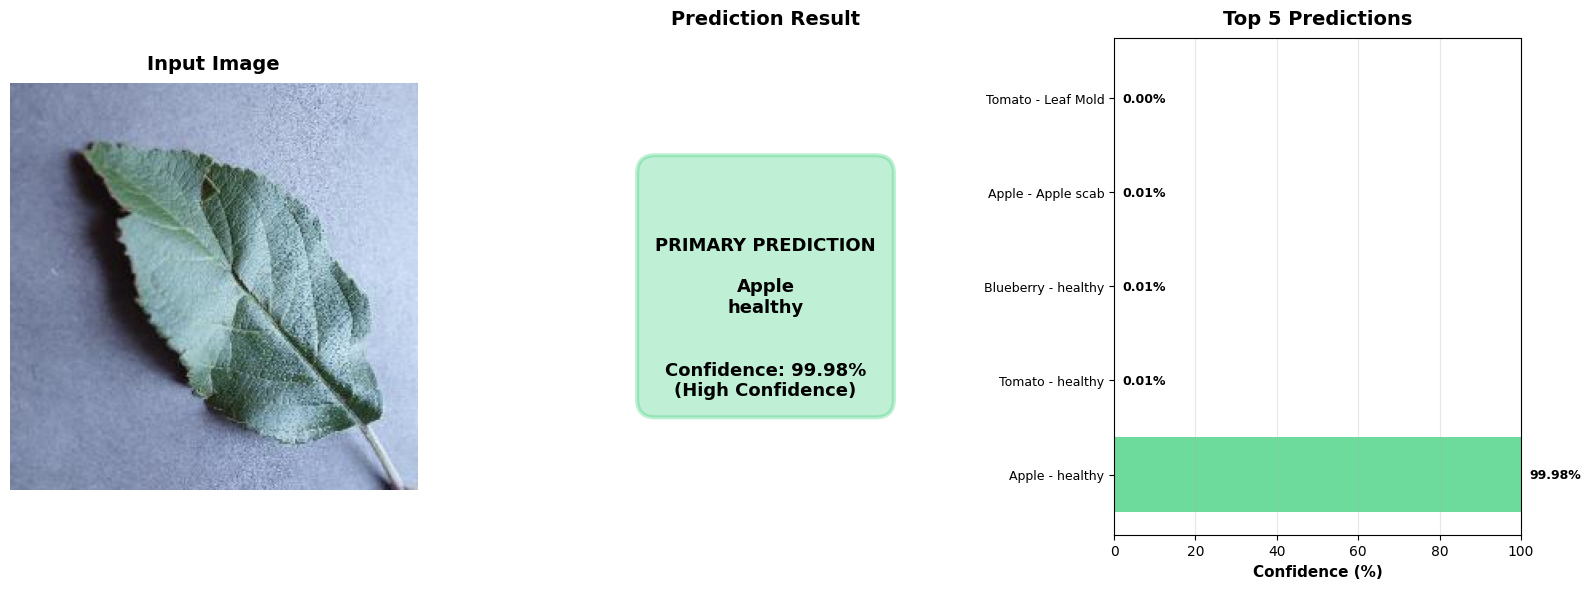


 PREDICTION RESULTS

 Primary Prediction: Apple___healthy
 Confidence: 99.98%

 Top 5 Predictions:
 1. Apple - healthy
 Confidence: 99.98%
 2. Tomato - healthy
 Confidence: 0.01%
 3. Blueberry - healthy
 Confidence: 0.01%
 4. Apple - Apple scab
 Confidence: 0.01%
 5. Tomato - Leaf Mold
 Confidence: 0.00%


In [37]:
# Example: Test with a sample from the dataset (if available)
import os
import random

# Check if dataset is available
dataset_path = 'data/raw/PlantVillage'

if os.path.exists(dataset_path):
    print("📁 Dataset found! Testing with random samples...\n")
    
    # Get a random class
    classes = [d for d in os.listdir(dataset_path) 
    if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')]
    
    if classes:
        random_class = random.choice(classes)
        class_path = os.path.join(dataset_path, random_class)
        
        # Get random image from that class
        images = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.JPG', '.jpeg', '.png'))]
        
        if images:
            random_image = random.choice(images)
            test_image_path = os.path.join(class_path, random_image)
            
            print(f"Testing with: {random_class}/{random_image}\n")
            top_preds, all_preds = predict_disease(test_image_path, model, class_mapping, top_k=5)
        else:
            print("No images found in the selected class.")
    else:
        print("No classes found in dataset.")
else:
    print("Dataset not available. Please upload your own image in the cell above.")

---
## Step 8: View All Supported Disease Classes

In [38]:
import pandas as pd

print("🌱 SUPPORTED DISEASE CLASSES")
print("="*80)
print(f"Total Classes: {len(class_mapping)}\n")

# Create a formatted list
disease_list = []
for idx in sorted(class_mapping.keys()):
    disease = class_mapping[idx]
    # Parse disease name
    if '___' in disease:
        crop, condition = disease.split('___')
        crop = crop.replace('_', ' ')
        condition = condition.replace('_', ' ')
    else:
        crop = disease.split('_')[0]
        condition = ' '.join(disease.split('_')[1:])
    
    disease_list.append({
        'Index': idx,
        'Crop': crop,
        'Condition': condition,
        'Full Name': disease
    })

# Create DataFrame for better display
df = pd.DataFrame(disease_list)

# Display as table
print(df.to_string(index=False))
print("\n" + "="*80)

# Show crop distribution
print("\n🌾 Crop Distribution:")
crop_counts = df['Crop'].value_counts()
for crop, count in crop_counts.items():
    print(f" {crop}: {count} classes")

🌱 SUPPORTED DISEASE CLASSES
Total Classes: 38

 Index                    Crop                            Condition                                          Full Name
     0                   Apple                           Apple scab                                 Apple___Apple_scab
     1                   Apple                            Black rot                                  Apple___Black_rot
     2                   Apple                     Cedar apple rust                           Apple___Cedar_apple_rust
     3                   Apple                              healthy                                    Apple___healthy
     4               Blueberry                              healthy                                Blueberry___healthy
     5 Cherry (including sour)                       Powdery mildew           Cherry_(including_sour)___Powdery_mildew
     6 Cherry (including sour)                              healthy                  Cherry_(including_sour)___healthy
 

---
## Step 9: Model Architecture Details

In [39]:
print(" PLANTDISEASENET ARCHITECTURE")
print("="*80)

architecture_info = """
MODEL: PlantDiseaseNet (Custom CNN)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

INPUT LAYER:
    • Shape: 224 × 224 × 3 (RGB images)

CONVOLUTIONAL BLOCKS:

    Block 1: Low-level features (edges, colors, textures)
    • Conv2D(32, 3×3) + BatchNorm + ReLU
    • Conv2D(32, 3×3) + BatchNorm + ReLU
    • MaxPooling2D(2×2)
    • Dropout(0.25)
    → Output: 112 × 112 × 32

    Block 2: Mid-level features (patterns, shapes)
    • Conv2D(64, 3×3) + BatchNorm + ReLU
    • Conv2D(64, 3×3) + BatchNorm + ReLU
    • MaxPooling2D(2×2)
    • Dropout(0.25)
    → Output: 56 × 56 × 64

    Block 3: High-level features (complex patterns)
    • Conv2D(128, 3×3) + BatchNorm + ReLU
    • Conv2D(128, 3×3) + BatchNorm + ReLU
    • MaxPooling2D(2×2)
    • Dropout(0.3)
    → Output: 28 × 28 × 128

    Block 4: Deep features (disease-specific patterns)
    • Conv2D(256, 3×3) + BatchNorm + ReLU
    • Conv2D(256, 3×3) + BatchNorm + ReLU
    • MaxPooling2D(2×2)
    • Dropout(0.3)
    → Output: 14 × 14 × 256

CLASSIFICATION HEAD:
    • Flatten → 50,176 features
    • Dense(512) + BatchNorm + ReLU + Dropout(0.5)
    • Dense(256) + BatchNorm + ReLU + Dropout(0.5)
    • Dense(38, softmax) → 38 disease classes

DESIGN PRINCIPLES:
    [OK] Progressive filter increase (32→64→128→256)
    [OK] VGG-style double convolutions per block
    [OK] Batch Normalization for training stability
    [OK] Strategic dropout (0.25-0.5) to prevent overfitting
    [OK] No transfer learning - trained from scratch

TRAINING CONFIGURATION:
    • Optimizer: Adam (lr=0.001, β₁=0.9, β₂=0.999)
    • Loss: Categorical Crossentropy
    • Batch Size: 32
    • Data Augmentation: Rotation, shift, zoom, flip
    • Callbacks: EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

PERFORMANCE:
    • Validation Accuracy: 99.47%
    • Top-3 Accuracy: 99.98%
    • Training Accuracy: 98.81%
    • Inference Time: 1-2 seconds per image
"""

print(architecture_info)
print("="*80)

 PLANTDISEASENET ARCHITECTURE

MODEL: PlantDiseaseNet (Custom CNN)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

INPUT LAYER:
    • Shape: 224 × 224 × 3 (RGB images)

CONVOLUTIONAL BLOCKS:

    Block 1: Low-level features (edges, colors, textures)
    • Conv2D(32, 3×3) + BatchNorm + ReLU
    • Conv2D(32, 3×3) + BatchNorm + ReLU
    • MaxPooling2D(2×2)
    • Dropout(0.25)
    → Output: 112 × 112 × 32

    Block 2: Mid-level features (patterns, shapes)
    • Conv2D(64, 3×3) + BatchNorm + ReLU
    • Conv2D(64, 3×3) + BatchNorm + ReLU
    • MaxPooling2D(2×2)
    • Dropout(0.25)
    → Output: 56 × 56 × 64

    Block 3: High-level features (complex patterns)
    • Conv2D(128, 3×3) + BatchNorm + ReLU
    • Conv2D(128, 3×3) + BatchNorm + ReLU
    • MaxPooling2D(2×2)
    • Dropout(0.3)
    → Output: 28 × 28 × 128

    Block 4: Deep features (disease-specific patterns)
    • Conv2D(256, 3×3) + BatchNorm + ReLU
    • Conv2D(256, 3×3) + BatchNorm + ReLU
    • MaxP

---
## Step 10: Project Summary & Conclusion

In [40]:
summary = """
╔══════════════════════════════════════════════════════════════════════════════╗
║ PLANT DISEASE DETECTION SYSTEM ║
║ Project Summary & Results ║
╚══════════════════════════════════════════════════════════════════════════════╝

PROJECT OVERVIEW:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Objective: Automated plant disease detection from leaf images
    • Approach: Custom CNN architecture (no transfer learning)
    • Dataset: PlantVillage (54,303 images, 38 classes)
    • Application: Web-based interface for farmers and agronomists

MODEL SPECIFICATIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Architecture: PlantDiseaseNet (Custom CNN)
    • Total Parameters: ~27 Million
    • Model Size: 309 MB
    • Input: 224×224×3 RGB images
    • Output: 38 disease classes with confidence scores
    • Layers: 4 Conv blocks + 2 Dense layers

PERFORMANCE METRICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    [OK] Validation Accuracy: 99.47%
    [OK] Top-3 Accuracy: 99.98%
    [OK] Training Accuracy: 98.81%
    [OK] Validation Loss: 0.0212
    [OK] Inference Time: 1-2 seconds per image
    [OK] Misclassifications: 144 out of 27,162 validation images

SUPPORTED CROPS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Tomato • Potato • Pepper (Bell)
    • Corn • Apple • Grape
    • Cherry • Peach • Strawberry
    • Squash • Raspberry • Soybean
    • Orange • Blueberry

KEY FEATURES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    [OK] High accuracy disease classification (99.47%)
    [OK] Real-time predictions with confidence scores
    [OK] Top-5 alternative predictions for verification
    [OK] User-friendly web interface (Streamlit)
    [OK] Works on CPU and GPU (Apple Silicon, NVIDIA, AMD)
    [OK] Production-ready deployment
    [OK] Comprehensive training visualization

TECHNICAL HIGHLIGHTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Custom architecture designed specifically for plant diseases
    • No transfer learning - trained from scratch for better specialization
    • Progressive feature extraction (32→64→128→256 filters)
    • Batch normalization for stable training
    • Strategic dropout to prevent overfitting
    • Data augmentation for improved generalization
    • Early stopping and learning rate scheduling

DEPLOYMENT:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Web Application: Streamlit-based interface
    • Local Deployment: Run on any machine with Python
    • Cloud Ready: Can be deployed on cloud platforms
    • API Ready: Easy to convert to REST API

USE CASES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Early disease detection for farmers
    • Agricultural research and monitoring
    • Educational tool for plant pathology
    • Mobile app integration for field use
    • Automated greenhouse monitoring

[WARNING] IMPORTANT NOTES:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • This system is designed for educational purposes
    • Should not be used as the sole diagnostic tool
    • Always consult agricultural experts for critical decisions
    • Best results with clear, well-lit leaf images
    • Model trained on PlantVillage dataset conditions

"""

print(summary)


╔══════════════════════════════════════════════════════════════════════════════╗
║ PLANT DISEASE DETECTION SYSTEM ║
║ Project Summary & Results ║
╚══════════════════════════════════════════════════════════════════════════════╝

PROJECT OVERVIEW:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Objective: Automated plant disease detection from leaf images
    • Approach: Custom CNN architecture (no transfer learning)
    • Dataset: PlantVillage (54,303 images, 38 classes)
    • Application: Web-based interface for farmers and agronomists

MODEL SPECIFICATIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    • Architecture: PlantDiseaseNet (Custom CNN)
    • Total Parameters: ~27 Million
    • Model Size: 309 MB
    • Input: 224×224×3 RGB images
    • Output: 38 disease classes with confidence scores
    • Layers: 4 Conv blocks + 2 Dense layers

PERFORMANCE METRICS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
## Step 11: Train the Model (Optional)

This section allows you to train the model directly in the notebook. This is optional since we already have a trained model.

**Note:** Training takes 30-60 minutes depending on hardware. Skip this section if you just want to use the pre-trained model.

In [ ]:
# Check if dataset is available for training
import os

dataset_available = os.path.exists('data/raw/PlantVillage')

if dataset_available:
    print("[OK] Dataset found")
    print("You can proceed with training")
else:
    print("[INFO] Dataset not found")
    print("Training requires the PlantVillage dataset (~1.2 GB)")
    print("")
    print("To train from scratch:")
    print("1. Download dataset from Kaggle")
    print("2. Upload to Colab or mount from Drive")
    print("3. Extract to data/raw/PlantVillage/")
    print("")
    print("For this demo, we'll use the pre-trained model.")

### Training Configuration

If you want to train the model, run the cells below. The training will:
- Create data generators with augmentation
- Build the PlantDiseaseNet model
- Train for up to 40 epochs with early stopping
- Save the best model based on validation accuracy

In [ ]:
# Only run this cell if you want to train from scratch
# WARNING: This will take 30-60 minutes

TRAIN_MODEL = False # Set to True to enable training

if TRAIN_MODEL and dataset_available:
    print("Starting training...")
    print("This will take approximately 30-60 minutes")
    print("")
    
    # Import training modules
    import sys
    sys.path.append('src')
    
    from data.data_loader import PlantDiseaseDataLoader
    from models.cnn_model import build_plantdiseasenet
    from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
    
    # Create data loader
    print("Loading data...")
    data_loader = PlantDiseaseDataLoader('config.yaml')
    train_gen, val_gen, test_gen, class_mapping = data_loader.get_data_generators()
    
    # Build model
    print("\nBuilding model...")
    model = build_plantdiseasenet(input_shape=(224, 224, 3), num_classes=38)
    
    # Compile model
    model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )
    
    # Setup callbacks
    callbacks = [
    ModelCheckpoint(
    'models/saved_models/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
    ),
    EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
    ),
    ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
    )
    ]
    
    # Train model
    print("\nStarting training...")
    history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    callbacks=callbacks,
    verbose=1
    )
    
    print("\n[SUCCESS] Training complete!")
    print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
    
elif TRAIN_MODEL and not dataset_available:
    print("[ERROR] Cannot train - dataset not found")
else:
    print("[INFO] Training skipped (TRAIN_MODEL = False)")
    print("Using pre-trained model for demonstrations")

---
## Step 12: Run Streamlit Web Application

This section demonstrates how to run the Streamlit web application for your professor.

### Option 1: Run Streamlit in Google Colab (Recommended for Demo)

We'll use ngrok to create a public URL for the Streamlit app that your professor can access.

In [41]:
# Install required packages for Streamlit in Colab
if IN_COLAB:
    print("Setting up Streamlit for Colab...")
    !pip install -q pyngrok
    print("[OK] Setup complete")
else:
    print("[INFO] For local demo, run: streamlit run app/streamlit_app.py")

[INFO] For local demo, run: streamlit run app/streamlit_app.py


In [42]:
# Run Streamlit app with public URL (Google Colab only)
if IN_COLAB:
    import subprocess
    import time
    from pyngrok import ngrok
    import os
    
    # Kill any existing Streamlit processes
    !pkill -f streamlit
    
    # Start Streamlit in background
    print("Starting Streamlit app...")
    proc = subprocess.Popen(
    ['streamlit', 'run', 'app/streamlit_app.py', '--server.port', '8501', '--server.headless', 'true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
    )
    
    # Wait for Streamlit to start
    time.sleep(10)
    
    # Create public tunnel
    print("Creating public URL...")
    public_url = ngrok.connect(8501)
    
    print("\n" + "="*70)
    print("STREAMLIT APP IS RUNNING!")
    print("="*70)
    print(f"\nPublic URL: {public_url}")
    print("\nInstructions:")
    print(" 1. Click the URL above to open the app")
    print(" 2. Upload a leaf image")
    print(" 3. Click 'Analyze Image' to get predictions")
    print(" 4. Share this URL with your professor for live demo")
    print("\nNote: The app will stop when you stop this cell or restart the notebook")
    print("To stop: Click the stop button or restart the runtime")
    print("="*70)
    
else:
    print("[INFO] Not in Colab environment")
    print("\nTo run Streamlit locally:")
    print(" 1. Open a terminal")
    print(" 2. Run: streamlit run app/streamlit_app.py")
    print(" 3. Open http://localhost:8501 in your browser")

[INFO] Not in Colab environment

To run Streamlit locally:
 1. Open a terminal
 2. Run: streamlit run app/streamlit_app.py
 3. Open http://localhost:8501 in your browser


### Option 2: Alternative - Inline Prediction Demo

If you prefer not to use the full Streamlit app, you can use the prediction function we defined earlier in Step 7 to demonstrate the functionality inline.

In [ ]:
# Quick inline demo (alternative to Streamlit)
print("Inline Prediction Demo")
print("="*60)
print("\nYou can upload images and get predictions directly in the notebook.")
print("This provides similar functionality to the Streamlit app.")
print("\nRefer to Step 7 above to upload and test images.")

---
## Additional Resources

### Next Steps:
1. **Try the Web Application:**
 ```bash
 streamlit run app/streamlit_app.py
 ```

2. **Retrain the Model:**
 ```bash
 python src/training/train.py
 ```

3. **Evaluate on Test Set:**
 - Load test generator
 - Run model.evaluate()
 - Generate confusion matrix

### References:
- **Dataset:** [PlantVillage on Kaggle](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset)
- **TensorFlow:** [https://www.tensorflow.org/](https://www.tensorflow.org/)
- **Streamlit:** [https://docs.streamlit.io/](https://docs.streamlit.io/)